# TikTok Political Affiliation Classifier
This notebook:
1. Loads a SQLite database from Google Drive containing TikTok video descriptions
2. Embeds the text using a sentence-transformer model
3. Trains multiple classifiers (MLP, Logistic Regression, SVM, Random Forest, Gradient Boosting)
4. Evaluates and compares model performance

## 1. Install Dependencies

In [1]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn tqdm

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration
**Update `DB_PATH` to point to your SQLite `.db` file in Google Drive.**

In [3]:
# ============================================================
# CONFIGURATION — update these before running
# ============================================================

# Path to your SQLite database in Google Drive
DB_PATH = '/content/drive/MyDrive/colabshortcuts/tiktok_breadth_first.db'

# Name of the table containing TikTok data
TABLE_NAME = 'videos'  # <-- UPDATE if different

# Column names in your table
TEXT_COLUMN = 'video_description'     # <-- column with video description text
LABEL_COLUMN = 'to_username'          # <-- column with 'Democrat' / 'Republican' labels

# Sentence-transformer model to use for embeddings
# Options (larger = better quality, slower):
#   'all-MiniLM-L6-v2'          — fast, lightweight (default)
#   'all-mpnet-base-v2'         — better quality, moderate speed
#   'paraphrase-multilingual-MiniLM-L12-v2'  — multilingual support
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# Train/test split ratio
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Batch size for embedding (reduce if you run out of GPU memory)
EMBEDDING_BATCH_SIZE = 64

# ============================================================

## 4. Load Data from SQLite

In [6]:
import sqlite3
import pandas as pd
import numpy as np

# Connect and load
conn = sqlite3.connect(DB_PATH)

# Preview available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tables in database:')
print(tables.to_string(index=False))

# Load the data

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr ON fr.from_username = videos.reposter_username
WHERE fr.to_username = 'teamtrump'
ORDER BY RANDOM()
LIMIT 10000
"""

trump_df = pd.read_sql(query, conn)

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr ON fr.from_username = videos.reposter_username
WHERE fr.to_username = 'kamalahq'
ORDER BY RANDOM()
LIMIT 10000
"""

kamala_df = pd.read_sql(query, conn)

df = pd.concat([trump_df, kamala_df])
conn.close()

print(f'\nLoaded {len(df):,} rows')
print(f'Columns: {list(df.columns)}')
df.head()

Tables in database:
            name
           users
follow_relations
          videos

Loaded 20,000 rows
Columns: ['video_description', 'to_username']


,video_description,to_username
0,#Ligue1 #Jawline #SportsTikTok #Mog #Fortnite,teamtrump
1,#fyp #foryoupage #foryou #fypage #jinglebells ...,teamtrump
2,,teamtrump
3,GT3 RS lost in space 🛰️ Inspiration: @LUMINANC...,teamtrump
4,Yamaha R1 edit 😶‍🌫️ #yamaha #yamahar1 #r1 #r1m...,teamtrump


In [8]:
# Drop rows with missing text or labels
before = len(df)
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
df = df[df[TEXT_COLUMN].str.strip() != '']
print(f'\nDropped {before - len(df)} rows with missing text/labels. Remaining: {len(df):,}')

# Inspect label distribution
print('Label distribution:')
print(df[LABEL_COLUMN].value_counts())
print(f'\nClass balance: {df[LABEL_COLUMN].value_counts(normalize=True).mul(100).round(1).to_dict()}')


Dropped 1452 rows with missing text/labels. Remaining: 18,548
Label distribution:
to_username
kamalahq     9404
teamtrump    9144
Name: count, dtype: int64

Class balance: {'kamalahq': 50.7, 'teamtrump': 49.3}


## 5. Embed Text with Sentence-Transformers

In [9]:
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

print(f'Loading embedding model: {EMBEDDING_MODEL} ...')
embedder = SentenceTransformer(EMBEDDING_MODEL, device=device)

texts = df[TEXT_COLUMN].tolist()

print(f'Embedding {len(texts):,} texts (batch size={EMBEDDING_BATCH_SIZE}) ...')
embeddings = embedder.encode(
    texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'Embedding matrix shape: {embeddings.shape}')

Using device: cuda
Loading embedding model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 18,548 texts (batch size=64) ...


Batches:   0%|          | 0/290 [00:00<?, ?it/s]

Embedding matrix shape: (18548, 384)


## 6. Prepare Train / Test Split

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df[LABEL_COLUMN])
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

Label encoding: {'kamalahq': np.int64(0), 'teamtrump': np.int64(1)}
Train size: 14,838  |  Test size: 3,710


## 7. Train Classifiers

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import time

classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
    ]),
    'MLP (1 hidden layer)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(256,), max_iter=200,
                              early_stopping=True, random_state=RANDOM_STATE))
    ]),
    'MLP (2 hidden layers)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                              early_stopping=True, random_state=RANDOM_STATE))
    ]),
    'Linear SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(),
}

results = {}

for name, model in classifiers.items():
    print(f'Training {name} ...', end=' ')
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    # AUC requires probability scores; LinearSVC uses decision_function
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = float('nan')

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':   auc,
        'Train time (s)': round(train_time, 2),
        'model': model,
        'y_pred': y_pred,
    }
    print(f'done in {train_time:.1f}s  |  Acc={results[name]["Accuracy"]:.4f}  F1={results[name]["F1 (macro)"]:.4f}')

Training Logistic Regression ... done in 0.7s  |  Acc=0.6485  F1=0.6483
Training MLP (1 hidden layer) ... done in 4.4s  |  Acc=0.6528  F1=0.6528
Training MLP (2 hidden layers) ... done in 7.5s  |  Acc=0.6553  F1=0.6532
Training Linear SVM ... done in 2.7s  |  Acc=0.6477  F1=0.6475
Training Random Forest ... done in 90.1s  |  Acc=0.6453  F1=0.6439
Training Gradient Boosting ... done in 636.7s  |  Acc=0.6501  F1=0.6498
Training Naive Bayes ... done in 0.0s  |  Acc=0.6407  F1=0.6403


## 8. Results Summary

In [12]:
summary = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ('model', 'y_pred')}
    for name, metrics in results.items()
}).T.sort_values('F1 (macro)', ascending=False)

print('=== Model Comparison ===')
print(summary.to_string(float_format='{:.4f}'.format))

=== Model Comparison ===
                       Accuracy  F1 (macro)  ROC-AUC  Train time (s)
MLP (2 hidden layers)    0.6553      0.6532   0.7137          7.4700
MLP (1 hidden layer)     0.6528      0.6528   0.7161          4.4000
Gradient Boosting        0.6501      0.6498   0.7101        636.6600
Logistic Regression      0.6485      0.6483   0.7124          0.6700
Linear SVM               0.6477      0.6475   0.7123          2.7400
Random Forest            0.6453      0.6439   0.7046         90.1100
Naive Bayes              0.6407      0.6403   0.6954          0.0400


## 9. Visualizations

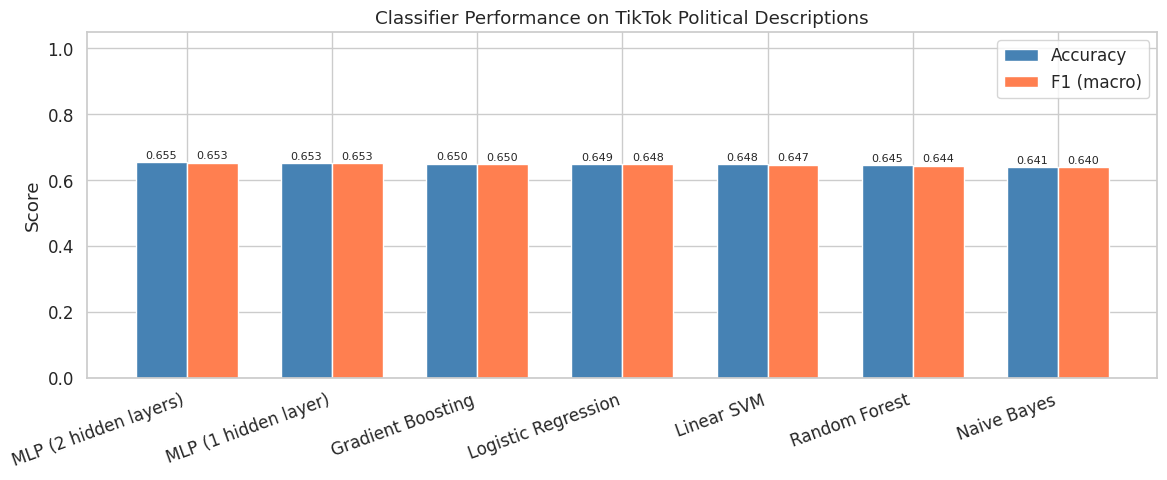

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

# --- Bar chart: Accuracy & F1 ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary))
width = 0.35
bars1 = ax.bar(x - width/2, summary['Accuracy'],  width, label='Accuracy',   color='steelblue')
bars2 = ax.bar(x + width/2, summary['F1 (macro)'], width, label='F1 (macro)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classifier Performance on TikTok Political Descriptions')
ax.legend()
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

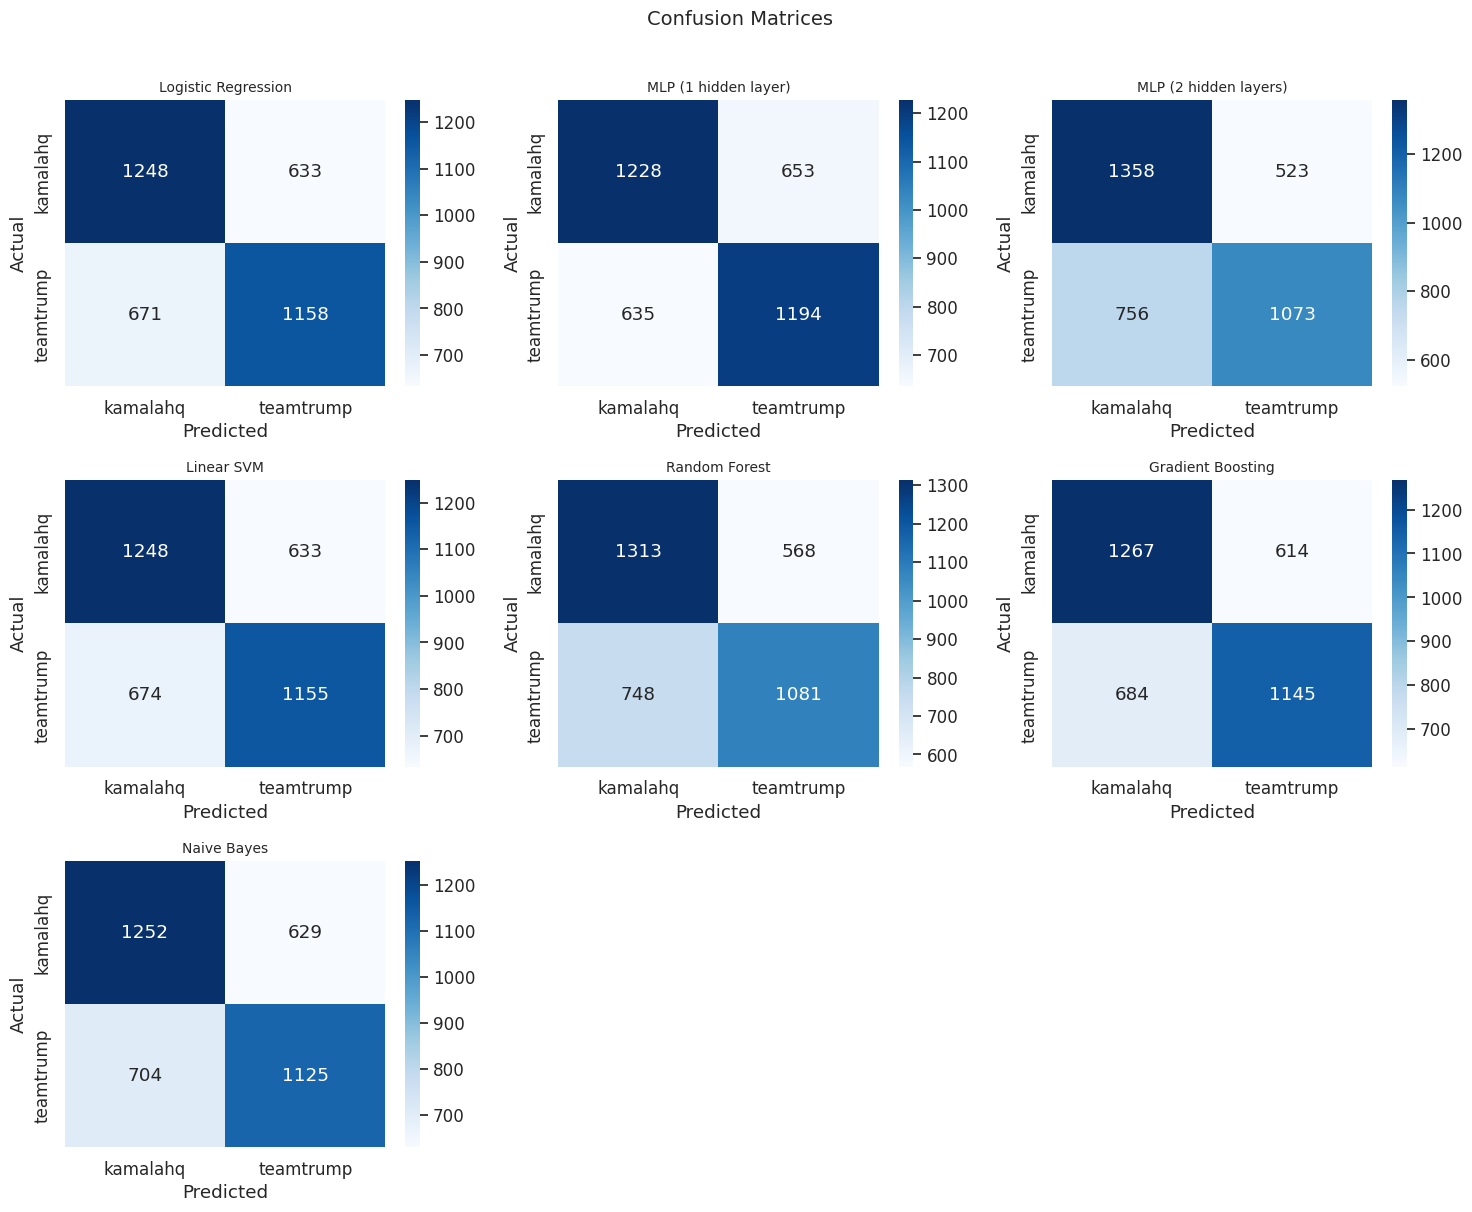

In [14]:
# --- Confusion matrices for all models ---
n_models = len(results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

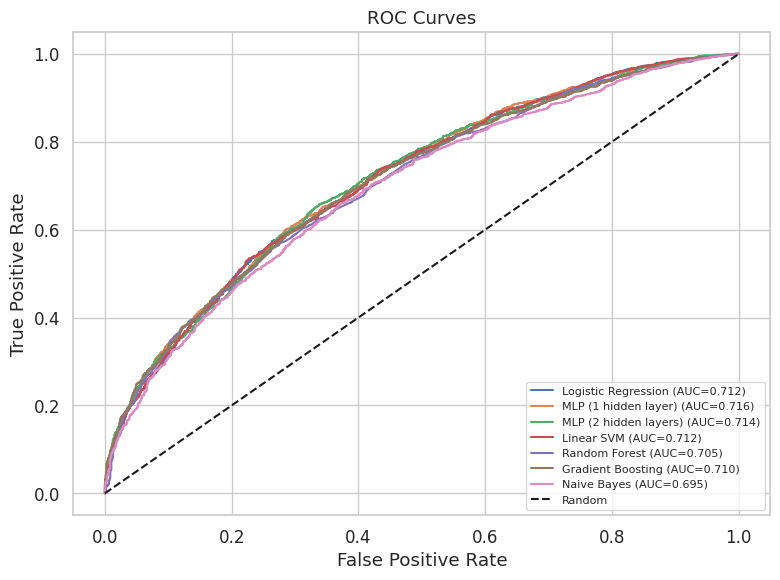

In [15]:
# --- ROC curves ---
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
for name, metrics in results.items():
    model = metrics['model']
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc = metrics['ROC-AUC']
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Detailed Classification Reports

In [16]:
for name, metrics in results.items():
    print(f'\n{'='*55}')
    print(f'  {name}')
    print('='*55)
    print(classification_report(y_test, metrics['y_pred'],
                                target_names=le.classes_))


  Logistic Regression
              precision    recall  f1-score   support

    kamalahq       0.65      0.66      0.66      1881
   teamtrump       0.65      0.63      0.64      1829

    accuracy                           0.65      3710
   macro avg       0.65      0.65      0.65      3710
weighted avg       0.65      0.65      0.65      3710


  MLP (1 hidden layer)
              precision    recall  f1-score   support

    kamalahq       0.66      0.65      0.66      1881
   teamtrump       0.65      0.65      0.65      1829

    accuracy                           0.65      3710
   macro avg       0.65      0.65      0.65      3710
weighted avg       0.65      0.65      0.65      3710


  MLP (2 hidden layers)
              precision    recall  f1-score   support

    kamalahq       0.64      0.72      0.68      1881
   teamtrump       0.67      0.59      0.63      1829

    accuracy                           0.66      3710
   macro avg       0.66      0.65      0.65      3710
we

## 11. UMAP Embedding Visualization (optional)
Visualize the embedding space colored by party label.

In [17]:
!pip install umap-learn -q

Fitting UMAP on full embedding set (this may take a minute) ...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


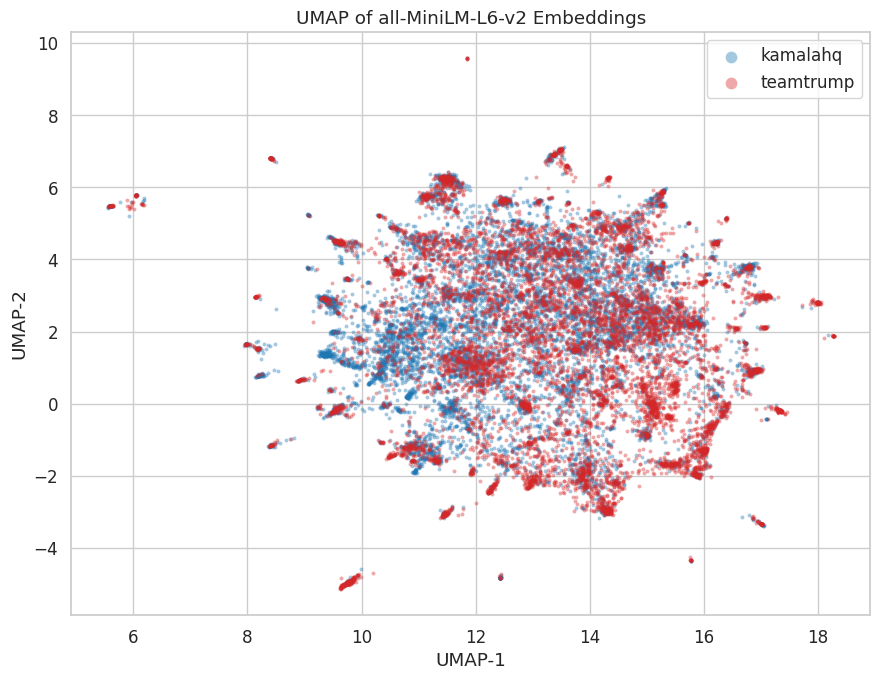

In [18]:
import umap

print('Fitting UMAP on full embedding set (this may take a minute) ...')
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_jobs=-1)
proj = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1f77b4', '#d62728']  # blue = Democrat, red = Republican
for i, label in enumerate(le.classes_):
    mask = (y == i)
    ax.scatter(proj[mask, 0], proj[mask, 1],
               c=colors[i], label=label, alpha=0.4, s=8, linewidths=0)
ax.set_title(f'UMAP of {EMBEDDING_MODEL} Embeddings')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.show()

## 12. Save Best Model

In [19]:
import joblib
import os

best_name = summary['F1 (macro)'].idxmax()
best_model = results[best_name]['model']
print(f'Best model: {best_name}  (F1={summary.loc[best_name, "F1 (macro)"]:.4f})')

save_path = '/content/drive/MyDrive/colabshortcuts/best_tiktok_classifier.joblib'
joblib.dump({'model': best_model, 'label_encoder': le, 'embedding_model': EMBEDDING_MODEL}, save_path)
print(f'Saved to {save_path}')

Best model: MLP (2 hidden layers)  (F1=0.6532)
Saved to /content/drive/MyDrive/best_tiktok_classifier.joblib


## 13. Inference on New Text (example)

In [ ]:
def predict_party(texts: list[str], model, embedder, le) -> pd.DataFrame:
    """Predict political affiliation for a list of TikTok descriptions."""
    embs = embedder.encode(texts, convert_to_numpy=True)
    preds = model.predict(embs)
    labels = le.inverse_transform(preds)
    rows = []
    for text, label in zip(texts, labels):
        rows.append({'text': text[:80] + ('...' if len(text) > 80 else ''), 'predicted_party': label})
    return pd.DataFrame(rows)

# Example usage
sample_texts = [
    "Support our veterans and protect the second amendment! 🇺🇸",
    "Climate change is real and we need green energy now #ClimateAction",
    "Build the wall, secure our borders, America first!",
    "Healthcare is a human right, Medicare for All 💙",
]

predict_party(sample_texts, best_model, embedder, le)